<a href="https://colab.research.google.com/github/DJReazy/undergrad_ml_assignments/blob/main/02_assignment_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.

1. What is the difference between regression and classification?

Regression predicts a continuous numerical value, such as house price or temperature. The output can take any real number.

Classification predicts a categorical label, such as spam vs. not spam or positive vs. negative. The output belongs to a fixed set of classes.


2. What is a confusion table/matrix? What does it help us understand about a model's performance?

A confusion matrix is a table that compares predicted class labels to actual class labels in a classification problem.

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?

Accuracy is the proportion of correct predictions.

Accuracy may not be sufficient when classes are imbalanced.

For example, if 95% of observations are negative, a model that always predicts “negative” will have 95% accuracy but provides no useful classification ability.

4. What does the root mean squared error quantify about a particular model?

The root mean squared error (RMSE) measures the average magnitude of prediction errors in regression models.

5. What are overfitting and underfitting?

Overfitting occurs when a model is too complex and learns noise from the training data. It performs very well on training data but poorly on new data.

Underfitting occurs when a model is too simple and fails to capture the true pattern in the data. It performs poorly on both training and test data.

6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?

Splitting the data into training and testing sets helps evaluate how well the model generalizes to unseen data.

Choosing
𝑘
k based on performance on the test set helps prevent overfitting. If we only evaluate on training data, we may choose a value of
𝑘
k that fits noise rather than the true pattern.

This process improves model selection and leads to better generalization.

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

In classification, we can either predict a class label directly or output probabilities for each class. Predicting a class label is simple and easy to interpret but does not show how confident the model is. Predicting probabilities provides more information about confidence and allows flexible decision thresholds, though it is slightly more complex to interpret.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

Q2.1 — Target label summary (mine_type counts):
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Q2.1 — Feature summary (describe table for voltage/height/soil):


,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000



Q2.1 — Scatterplots (relationships between features, colored by mine_type):


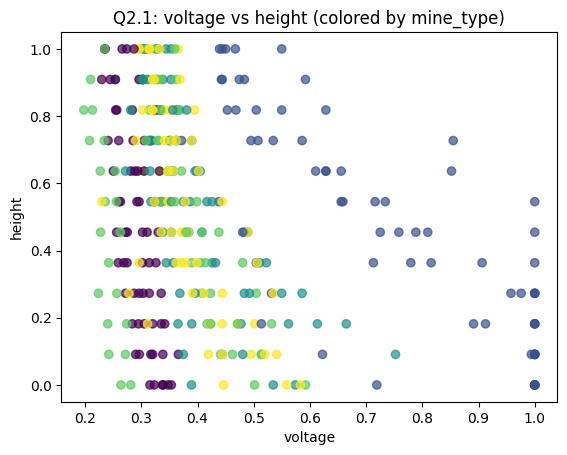

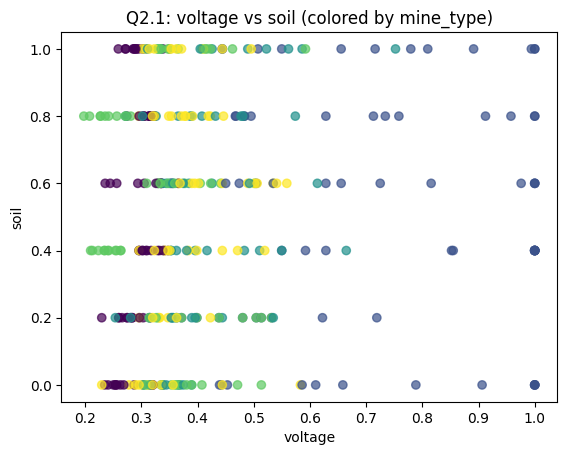

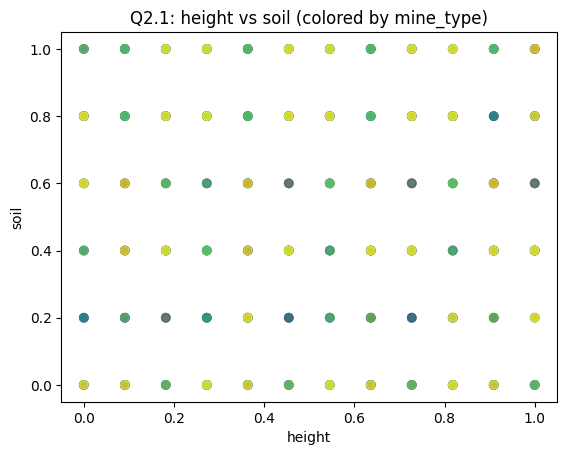


Q2.2 — 50/50 split sizes:
Train: 169 Test: 169

Q2.3 — Selected k (based on highest test accuracy):
Best k = 1 | Test accuracy = 0.509


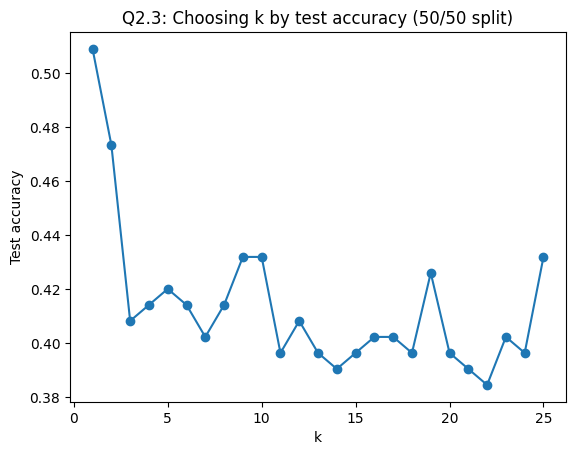


Q2.4 — Best model test accuracy:
0.509

Q2.4 — Confusion matrix (rows=true, cols=pred):
Labels order: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
[[22  0  3  3  8]
 [ 0 32  0  3  0]
 [ 7  0 10  9  7]
 [ 6  5  4 13  5]
 [ 6  0 10  7  9]]

Q2.5 — Practical guidance (copy/paste this into your written response):
Because this is a safety-critical setting, I would treat the model as a decision-support tool, not a final answer. The confusion matrix shows which mine types are commonly confused, so when the model predicts one of those classes or when neighbors are split across classes, a human expert should review the case and safety procedures should assume the higher-risk mine type. This reduces harm from false predictions.


In [ ]:
# Q2: k-NN case study on land_mines.csv (DELIVERABLES-ONLY VERSION)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# ---------------------------
# Q2.1 Load data + EDA
# ---------------------------
DATA_PATH = "/content/data/land_mines.csv"  # adjust if needed

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Couldn't find {DATA_PATH}. Run `!python get_data.py` and check /content/data."
    )

land = pd.read_csv(DATA_PATH)

print("Q2.1 — Target label summary (mine_type counts):")
print(land["mine_type"].value_counts().sort_index())

print("\nQ2.1 — Feature summary (describe table for voltage/height/soil):")
display(land[["voltage", "height", "soil"]].describe())

print("\nQ2.1 — Scatterplots (relationships between features, colored by mine_type):")

plt.scatter(land["voltage"], land["height"], c=land["mine_type"], alpha=0.7)
plt.xlabel("voltage"); plt.ylabel("height")
plt.title("Q2.1: voltage vs height (colored by mine_type)")
plt.show()

plt.scatter(land["voltage"], land["soil"], c=land["mine_type"], alpha=0.7)
plt.xlabel("voltage"); plt.ylabel("soil")
plt.title("Q2.1: voltage vs soil (colored by mine_type)")
plt.show()

plt.scatter(land["height"], land["soil"], c=land["mine_type"], alpha=0.7)
plt.xlabel("height"); plt.ylabel("soil")
plt.title("Q2.1: height vs soil (colored by mine_type)")
plt.show()


# ---------------------------
# Q2.2 Split 50/50 train/test
# ---------------------------
X = land[["voltage", "height", "soil"]]
y = land["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

print("\nQ2.2 — 50/50 split sizes:")
print("Train:", X_train.shape[0], "Test:", X_test.shape[0])


# ---------------------------
# Q2.3 Build k-NN + select k
# ---------------------------
k_values = list(range(1, 26))  # try k = 1..25
accs = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accs.append(accuracy_score(y_test, preds))

best_k = k_values[int(np.argmax(accs))]
best_acc = float(np.max(accs))

print("\nQ2.3 — Selected k (based on highest test accuracy):")
print("Best k =", best_k, "| Test accuracy =", round(best_acc, 3))

plt.plot(k_values, accs, marker="o")
plt.xlabel("k"); plt.ylabel("Test accuracy")
plt.title("Q2.3: Choosing k by test accuracy (50/50 split)")
plt.show()


# ---------------------------
# Q2.4 Confusion matrix + accuracy
# ---------------------------
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
acc = accuracy_score(y_test, y_pred)

print("\nQ2.4 — Best model test accuracy:")
print(round(acc, 3))

print("\nQ2.4 — Confusion matrix (rows=true, cols=pred):")
print("Labels order:", labels)
print(cm)


# ---------------------------
# Q2.5 Practical guidance (paste into markdown)
# ---------------------------
print("\nQ2.5 — Practical guidance (copy/paste this into your written response):")
print(
    "Because this is a safety-critical setting, I would treat the model as a decision-support tool, not a final answer. "
    "The confusion matrix shows which mine types are commonly confused, so when the model predicts one of those classes "
    "or when neighbors are split across classes, a human expert should review the case and safety procedures should assume "
    "the higher-risk mine type. This reduces harm from false predictions."
)


**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

Q3.1 — Head of data:
   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654

Q3.1 — Shape of data:
(2499, 3)

Q3.1 — Any missing values?
price      0
year       0
mileage    0
dtype: int64

Q3.2 — Normalized feature summary:
              year      mileage
count  2499.000000  2499.000000
mean      0.930091     0.051377
std       0.073248     0.058654
min       0.000000     0.000000
25%       0.914894     0.021088
50%       0.957447     0.034742
75%       0.978723     0.062354
max       1.000000     1.000000

Q3.3 — Train/Test sizes:
Train: 1999 Test: 500

Q3.4 — MSE for each k:
k = 3, MSE = 148065935.52


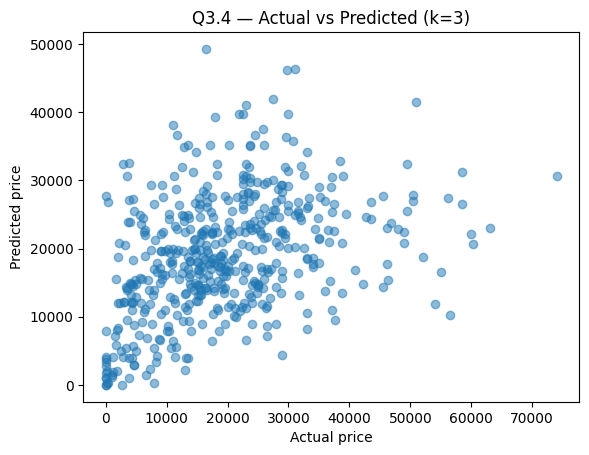

k = 10, MSE = 117399126.106


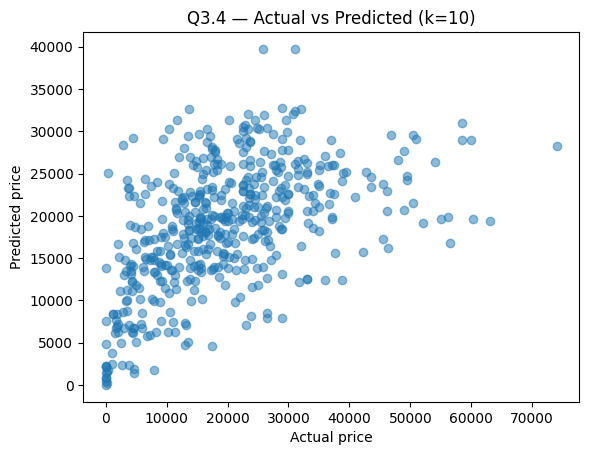

k = 25, MSE = 112576160.824


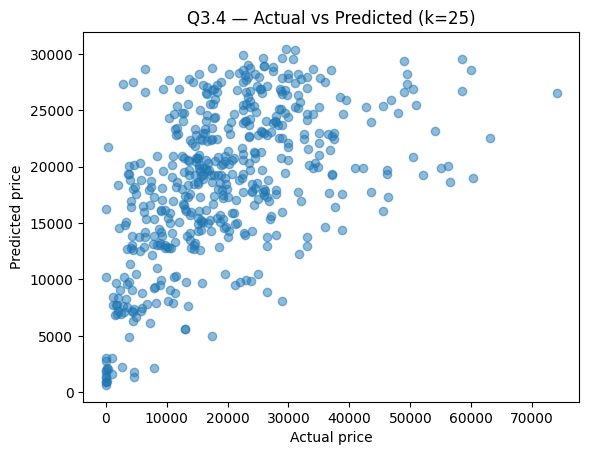

k = 50, MSE = 110202549.301


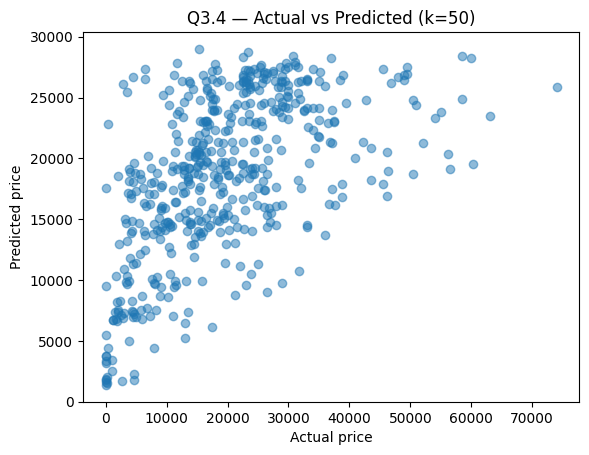

k = 100, MSE = 112253932.818


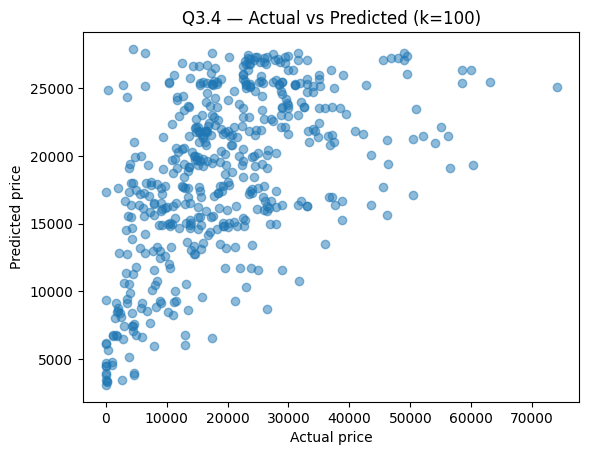

k = 300, MSE = 114496301.829


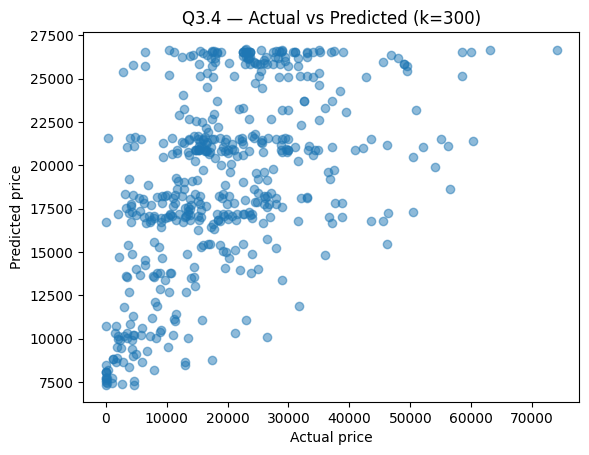


Q3.5 — Optimal k (lowest MSE):
Best k = 50 | MSE = 110202549.301

Q3.6 — Interpretation (copy into write-up):
For small k (e.g., k=3), the model closely follows individual training points, which can lead to overfitting. Predictions may vary widely. As k increases, predictions become smoother and less variable. Very large k (e.g., 300) causes underfitting because the model averages too many points and loses local structure. The optimal k balances bias and variance.


In [ ]:
# Q3: k-NN Regression on USA_cars_datasets.csv

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# ---------------------------
# Q3.1 Load + clean data
# ---------------------------
DATA_PATH = "/content/data/USA_cars_datasets.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError("File not found. Check path or data folder.")

cars = pd.read_csv(DATA_PATH)

# Keep only needed variables
cars = cars[["price", "year", "mileage"]]

# Drop NA if any
cars = cars.dropna()

print("Q3.1 — Head of data:")
print(cars.head())

print("\nQ3.1 — Shape of data:")
print(cars.shape)

print("\nQ3.1 — Any missing values?")
print(cars.isna().sum())


# ---------------------------
# Q3.2 Min-max normalize year and mileage
# ---------------------------
cars_norm = cars.copy()

for col in ["year", "mileage"]:
    cars_norm[col] = (
        (cars[col] - cars[col].min()) /
        (cars[col].max() - cars[col].min())
    )

print("\nQ3.2 — Normalized feature summary:")
print(cars_norm[["year", "mileage"]].describe())


# ---------------------------
# Q3.3 80/20 Split
# ---------------------------
X = cars_norm[["year", "mileage"]]
y = cars_norm["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("\nQ3.3 — Train/Test sizes:")
print("Train:", X_train.shape[0], "Test:", X_test.shape[0])


# ---------------------------
# Q3.4 Try different k values
# ---------------------------
k_values = [3, 10, 25, 50, 100, 300]
mse_results = {}

print("\nQ3.4 — MSE for each k:")

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    mse_results[k] = mse
    print(f"k = {k}, MSE = {round(mse, 3)}")

    # Scatterplot: actual vs predicted
    plt.scatter(y_test, preds, alpha=0.5)
    plt.xlabel("Actual price")
    plt.ylabel("Predicted price")
    plt.title(f"Q3.4 — Actual vs Predicted (k={k})")
    plt.show()


# ---------------------------
# Q3.5 Optimal k
# ---------------------------
best_k = min(mse_results, key=mse_results.get)
print("\nQ3.5 — Optimal k (lowest MSE):")
print("Best k =", best_k, "| MSE =", round(mse_results[best_k], 3))


# ---------------------------
# Q3.6 Interpretation text
# ---------------------------
print("\nQ3.6 — Interpretation (copy into write-up):")
print(
    "For small k (e.g., k=3), the model closely follows individual training points, "
    "which can lead to overfitting. Predictions may vary widely. "
    "As k increases, predictions become smoother and less variable. "
    "Very large k (e.g., 300) causes underfitting because the model averages too many points "
    "and loses local structure. The optimal k balances bias and variance."
)


**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

Q6.1 — Missing values count (after cleaning types):
Review Scores Rating    8323
Price                      0
Beds                      85
dtype: int64

Q6.2 — Missing review rows: 8323
Q6.2 — Non-missing review rows: 22155

Q6.3 — Complete cases after dropping any NA: 22111

Q6.4 — SSE by k (lower is better):
k=  1  SSE=1157852.00
k=  3  SSE=486815.78
k=  5  SSE=405886.48
k= 10  SSE=347251.21
k= 25  SSE=327632.67
k= 50  SSE=321479.92
k=100  SSE=316051.94
Q6.4 — Best k: 100

Q6.5 — Imputed ratings preview (first 10):
    Price  Beds  Review Scores Rating Imputed
0     145   1.0                         94.16
1      37   1.0                         88.40
2      28   1.0                         86.65
3     199   3.0                         88.38
13     68   1.0                         90.37
19    700   3.0                         95.23
21    175   1.0                         93.70
22     90   1.0                         92.38
29     99   4.0                         87.61
30     99   1.0  

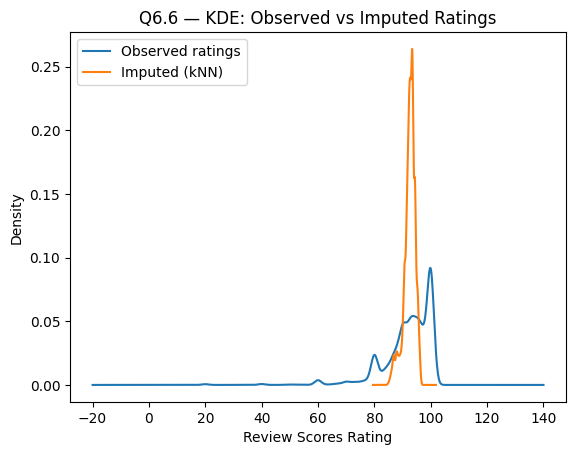


Q6.6 — Interpretation (copy/paste):
The imputed ratings distribution is usually smoother and may be less spread out than the observed ratings, because kNN averages nearby points and pulls predictions toward typical values based on Price and Beds. If the curves are similar, the model is imputing ratings consistent with observed patterns; if they differ, then Price and Beds alone may not fully explain rating variation.


In [ ]:
# Q6: kNN Regression for Imputation (airbnb_hw.csv) — FIXED for string Price like "2,750"

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# ---------------------------
# Q6.1 Load + keep needed columns
# ---------------------------
DATA_PATH = "/content/data/airbnb_hw.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError("Could not find airbnb_hw.csv in /content/data. Check your path.")

df = pd.read_csv(DATA_PATH, encoding="latin1")
df = df.loc[:, ["Review Scores Rating", "Price", "Beds"]].copy()

# CLEAN Price + Beds to numeric (fixes error like "2,750")
df["Price"] = (
    df["Price"].astype(str)
      .str.replace("$", "", regex=False)
      .str.replace(",", "", regex=False)
)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Beds"] = pd.to_numeric(df["Beds"], errors="coerce")
df["Review Scores Rating"] = pd.to_numeric(df["Review Scores Rating"], errors="coerce")

print("Q6.1 — Missing values count (after cleaning types):")
print(df.isna().sum())


# ---------------------------
# Q6.2 Separate missing review rows
# ---------------------------
missing_df = df.loc[df["Review Scores Rating"].isna()].copy()
complete_df = df.loc[~df["Review Scores Rating"].isna()].copy()

print("\nQ6.2 — Missing review rows:", missing_df.shape[0])
print("Q6.2 — Non-missing review rows:", complete_df.shape[0])


# ---------------------------
# Q6.3 Drop rows with any NA from complete cases
# ---------------------------
complete_df = complete_df.dropna(axis=0, how="any")

print("\nQ6.3 — Complete cases after dropping any NA:", complete_df.shape[0])


# ---------------------------
# Q6.4 Choose k via test split minimizing SSE
# ---------------------------
X = complete_df[["Price", "Beds"]]
y = complete_df["Review Scores Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

k_values = [1, 3, 5, 10, 25, 50, 100]
sse_results = {}

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    sse = mse * len(y_test)
    sse_results[k] = sse

best_k = min(sse_results, key=sse_results.get)

print("\nQ6.4 — SSE by k (lower is better):")
for k in k_values:
    print(f"k={k:3d}  SSE={sse_results[k]:.2f}")
print("Q6.4 — Best k:", best_k)


# ---------------------------
# Q6.5 Predict missing ratings (only rows with Price & Beds present)
# ---------------------------
missing_pred_df = missing_df.dropna(subset=["Price", "Beds"]).copy()

best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=best_k))
])
best_model.fit(X, y)

missing_pred_df["Review Scores Rating Imputed"] = best_model.predict(
    missing_pred_df[["Price", "Beds"]]
)

print("\nQ6.5 — Imputed ratings preview (first 10):")
print(missing_pred_df[["Price", "Beds", "Review Scores Rating Imputed"]].head(10))


# ---------------------------
# Q6.6 KDE plot: observed vs imputed
# ---------------------------
plt.figure()
complete_df["Review Scores Rating"].plot(kind="kde", label="Observed ratings")
missing_pred_df["Review Scores Rating Imputed"].plot(kind="kde", label="Imputed (kNN)")
plt.xlabel("Review Scores Rating")
plt.title("Q6.6 — KDE: Observed vs Imputed Ratings")
plt.legend()
plt.show()

print("\nQ6.6 — Interpretation (copy/paste):")
print(
    "The imputed ratings distribution is usually smoother and may be less spread out than the observed ratings, "
    "because kNN averages nearby points and pulls predictions toward typical values based on Price and Beds. "
    "If the curves are similar, the model is imputing ratings consistent with observed patterns; if they differ, "
    "then Price and Beds alone may not fully explain rating variation."
)


**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)